In [1]:
%%writefile config.py
import torch

# Воспроизводимость
SEED = 42

# Размер изображений
IMG_SIZE = 224

# Размеры подвыборок (балансировка)
TARGET_TRAIN_SIZE = 20000
TARGET_VAL_SIZE   = 10000
TARGET_TEST_SIZE  = 5000

# Параметры обучения
BATCH_SIZE = 128
LEARNING_RATE = 1e-4
NUM_EPOCHS = 10
WEIGHT_DECAY = 1e-5

# Параметры модели
CNN_FEATURE_DIM = 256
LSTM_HIDDEN_DIM = 256
TRANSFORMER_DIM = 256
NUM_HEADS = 8
NUM_LAYERS = 2
DROPOUT = 0.3

# Устройство
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Нормализация ImageNet (для предобученного EfficientNet)
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

CONFIG = {
    'seed': SEED,
    'img_size': IMG_SIZE,
    'target_train_size': TARGET_TRAIN_SIZE,
    'target_val_size': TARGET_VAL_SIZE,
    'target_test_size': TARGET_TEST_SIZE,
    'batch_size': BATCH_SIZE,
    'learning_rate': LEARNING_RATE,
    'num_epochs': NUM_EPOCHS,
    'weight_decay': WEIGHT_DECAY,
    'cnn_feature_dim': CNN_FEATURE_DIM,
    'lstm_hidden_dim': LSTM_HIDDEN_DIM,
    'transformer_dim': TRANSFORMER_DIM,
    'num_heads': NUM_HEADS,
    'num_layers': NUM_LAYERS,
    'dropout': DROPOUT,
    'device': str(DEVICE),
    'mean': MEAN,
    'std': STD,
}

Writing config.py


In [2]:
%%writefile data_utils.py
import random
from pathlib import Path
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
import kagglehub

from config import IMG_SIZE, MEAN, STD, TARGET_TRAIN_SIZE, TARGET_VAL_SIZE, TARGET_TEST_SIZE

# ------------------- Трансформации -------------------
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

# ------------------- Датасет -------------------
class DeepfakeDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.classes = ["Fake", "Real"]
        self.class_to_idx = {"Fake": 1, "Real": 0}
        self.samples = []

        for label in self.classes:
            label_dir = self.root_dir / label
            if label_dir.exists():
                for img_path in label_dir.glob("*.jpg"):
                    self.samples.append((str(img_path), self.class_to_idx[label]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

# ------------------- Балансированная обрезка -------------------
def balanced_subset(dataset, target_size, class_labels=[0,1]):
    """
    Возвращает Subset с target_size элементами, поровну из каждого класса.
    Если в классе недостаточно примеров, берутся все доступные.
    """
    indices_per_class = {cls: [] for cls in class_labels}
    for idx, (_, label) in enumerate(dataset.samples):
        if label in indices_per_class:
            indices_per_class[label].append(idx)

    samples_per_class = target_size // len(class_labels)
    selected_indices = []

    for cls in class_labels:
        available = indices_per_class.get(cls, [])
        if len(available) < samples_per_class:
            print(f"Предупреждение: класс {cls} имеет только {len(available)} примеров, требуется {samples_per_class}")
            selected_indices.extend(available)
        else:
            selected_indices.extend(random.sample(available, samples_per_class))

    if len(selected_indices) < target_size:
        remaining = list(set(range(len(dataset))) - set(selected_indices))
        selected_indices.extend(random.sample(remaining, target_size - len(selected_indices)))

    return Subset(dataset, selected_indices)

# ------------------- Функция загрузки датасета -------------------
def load_data():
    # Скачиваем датасет через kagglehub
    path = kagglehub.dataset_download("manjilkarki/deepfake-and-real-images")
    dataset_root = Path(path) / "Dataset"
    print(f"Корень датасета: {dataset_root}")

    # Создаём полные датасеты с трансформациями
    train_full = DeepfakeDataset(dataset_root / "Train", transform=train_transform)
    val_full   = DeepfakeDataset(dataset_root / "Validation", transform=val_test_transform)
    test_full  = DeepfakeDataset(dataset_root / "Test", transform=val_test_transform)

    print("Исходные размеры:")
    print(f"Train: {len(train_full)} изображений")
    print(f"Validation: {len(val_full)} изображений")
    print(f"Test: {len(test_full)} изображений")

    # Балансированная обрезка
    train_dataset = balanced_subset(train_full, TARGET_TRAIN_SIZE, class_labels=[0,1])
    val_dataset   = balanced_subset(val_full,   TARGET_VAL_SIZE,   class_labels=[0,1])
    test_dataset  = balanced_subset(test_full,  TARGET_TEST_SIZE,  class_labels=[0,1])

    print("\nПосле обрезки:")
    print(f"Train: {len(train_dataset)} изображений")
    print(f"Validation: {len(val_dataset)} изображений")
    print(f"Test: {len(test_dataset)} изображений")

    # Проверка баланса
    def check_balance(subset_dataset, name):
        labels = [subset_dataset.dataset.samples[idx][1] for idx in subset_dataset.indices]
        real_cnt = labels.count(0)
        fake_cnt = labels.count(1)
        print(f"{name}: REAL={real_cnt}, FAKE={fake_cnt}")

    check_balance(train_dataset, "Train")
    check_balance(val_dataset, "Validation")
    check_balance(test_dataset, "Test")

    return train_dataset, val_dataset, test_dataset

def create_dataloaders(train_dataset, val_dataset, test_dataset, batch_size, num_workers=2):
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=num_workers)
    test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=num_workers)
    return train_loader, val_loader, test_loader

Writing data_utils.py


In [3]:
%%writefile model.py
import torch
import torch.nn as nn
from torchvision import models

from config import CNN_FEATURE_DIM, LSTM_HIDDEN_DIM, TRANSFORMER_DIM, NUM_HEADS, NUM_LAYERS, DROPOUT

class CNNFeatureExtractor(nn.Module):
    """Извлечение пространственных признаков с помощью EfficientNet-B0"""
    def __init__(self, feature_dim=CNN_FEATURE_DIM):
        super().__init__()
        self.backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        self.backbone.classifier = nn.Identity()
        self.projection = nn.Linear(1280, feature_dim)

    def forward(self, x):
        features = self.backbone(x)
        return self.projection(features)


class HybridRNNTransformerDeepfake(nn.Module):
    """
    Гибридная модель для классификации deepfake:
    - CNN (EfficientNet) для извлечения пространственных признаков
    - BiLSTM для локальных временных зависимостей
    - Transformer для глобальных временных связей
    """
    def __init__(self,
                 cnn_feature_dim=CNN_FEATURE_DIM,
                 lstm_hidden_dim=LSTM_HIDDEN_DIM,
                 transformer_dim=TRANSFORMER_DIM,
                 num_heads=NUM_HEADS,
                 num_layers=NUM_LAYERS,
                 dropout=DROPOUT):
        super().__init__()

        # 1. CNN-экстрактор
        self.cnn_extractor = CNNFeatureExtractor(feature_dim=cnn_feature_dim)

        # 2. BiLSTM
        self.lstm = nn.LSTM(
            input_size=cnn_feature_dim,
            hidden_size=lstm_hidden_dim,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=dropout
        )
        self.lstm_projection = nn.Linear(lstm_hidden_dim * 2, transformer_dim)
        self.lstm_dropout = nn.Dropout(dropout)

        # 3. Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=transformer_dim,
            nhead=num_heads,
            dim_feedforward=transformer_dim * 4,
            dropout=dropout,
            activation='gelu',
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.transformer_dropout = nn.Dropout(dropout)

        # 4. Классификатор
        self.classifier = nn.Sequential(
            nn.Linear(transformer_dim * 2, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        batch_size = x.size(0)

        # Извлечение CNN-признаков
        cnn_features = self.cnn_extractor(x)          # [batch, cnn_feature_dim]
        seq_len = 8
        seq_features = cnn_features.unsqueeze(1).repeat(1, seq_len, 1)  # [batch, seq_len, cnn_feature_dim]
        noise = torch.randn_like(seq_features) * 0.01
        seq_features = seq_features + noise

        # BiLSTM
        lstm_out, (hidden, cell) = self.lstm(seq_features)
        lstm_pooled = torch.cat((hidden[-2, :, :], hidden[-1, :, :]), dim=1)  # [batch, 2*lstm_hidden]
        lstm_projected = self.lstm_projection(lstm_pooled)
        lstm_projected = self.lstm_dropout(lstm_projected)

        # Transformer (глобальные зависимости)
        trans_out = self.transformer(seq_features)   # [batch, seq_len, transformer_dim]
        trans_pooled = trans_out.mean(dim=1)         # [batch, transformer_dim]
        trans_pooled = self.transformer_dropout(trans_pooled)

        # Объединение и классификация
        combined = torch.cat((lstm_projected, trans_pooled), dim=1)
        logits = self.classifier(combined)
        return logits

Writing model.py


In [4]:
%%writefile train_utils.py
import torch
import torch.nn.functional as F
import numpy as np
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

class EarlyStopping:
    """Ранняя остановка с сохранением лучших весов"""
    def __init__(self, patience=7, min_delta=0.001, restore_best_weights=True):
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best_weights = restore_best_weights
        self.best_score = None
        self.counter = 0
        self.best_model_state = None

    def __call__(self, val_loss, model):
        if self.best_score is None:
            self.best_score = val_loss
            self.best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            return False
        elif val_loss > self.best_score - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                if self.restore_best_weights:
                    model.load_state_dict(self.best_model_state)
                return True
        else:
            self.best_score = val_loss
            self.best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
        return False


def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(dataloader, desc="Training"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def validate_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Validation"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = correct / total
    return epoch_loss, epoch_acc, all_preds, all_labels


def get_prediction_probs(model, dataloader, device):
    """Возвращает вероятности, истинные метки и тензоры изображений"""
    model.eval()
    probs = []
    labels = []
    images_list = []
    with torch.no_grad():
        for images, lbls in dataloader:
            images = images.to(device)
            outputs = model(images)
            probabilities = F.softmax(outputs, dim=1)
            probs.extend(probabilities.cpu().numpy())
            labels.extend(lbls.numpy())
            images_list.extend(images.cpu())
    return np.array(probs), np.array(labels), images_list


def plot_learning_curves(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    ax1.plot(history['train_loss'], label='Train Loss')
    ax1.plot(history['val_loss'], label='Val Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Кривые потерь')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(history['train_acc'], label='Train Accuracy')
    ax2.plot(history['val_acc'], label='Val Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_title('Кривые точности')
    ax2.legend()
    ax2.grid(True)
    plt.tight_layout()
    plt.show()


def evaluate_model(model, test_loader, criterion, device):
    test_loss, test_acc, test_preds, test_labels = validate_epoch(model, test_loader, criterion, device)
    print(f"Тестовая точность: {test_acc:.4f}")
    print(f"Тестовые потери: {test_loss:.4f}")
    print("\nClassification Report:")
    print(classification_report(test_labels, test_preds, target_names=['REAL', 'FAKE']))

    # Матрица ошибок
    cm = confusion_matrix(test_labels, test_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['REAL', 'FAKE'], yticklabels=['REAL', 'FAKE'])
    plt.xlabel('Предсказанные')
    plt.ylabel('Истинные')
    plt.title('Матрица ошибок')
    plt.show()

    # ROC-AUC
    fpr, tpr, _ = roc_curve(test_labels, test_preds)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC кривая для классификации deepfake')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

    return test_acc, test_preds, test_labels


def show_uncertain_examples(model, test_loader, device, num_examples=8):
    """Показывает изображения с наибольшей неуверенностью модели"""
    probs, true_labels, test_imgs = get_prediction_probs(model, test_loader, device)
    pred_labels = np.argmax(probs, axis=1)
    uncertainty = np.max(probs, axis=1)
    uncertainty_idx = np.argsort(uncertainty)[:num_examples]

    fig, axes = plt.subplots(2, num_examples//2, figsize=(16, 8))
    for i, idx in enumerate(uncertainty_idx):
        row, col = i // (num_examples//2), i % (num_examples//2)
        # Денормализация
        img = test_imgs[idx].permute(1, 2, 0).numpy()
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)

        axes[row, col].imshow(img)
        true_class = "Real" if true_labels[idx] == 0 else "Fake"
        pred_class = "Real" if pred_labels[idx] == 0 else "Fake"
        confidence = np.max(probs[idx])
        axes[row, col].set_title(f"True: {true_class}\nPred: {pred_class} ({confidence:.2f})")
        axes[row, col].axis('off')
    plt.suptitle("Примеры с наибольшей неуверенностью модели")
    plt.tight_layout()
    plt.show()

Writing train_utils.py


Загрузка датасета...
Корень датасета: /kaggle/input/datasets/manjilkarki/deepfake-and-real-images/Dataset
Исходные размеры:
Train: 140002 изображений
Validation: 39428 изображений
Test: 10905 изображений

После обрезки:
Train: 20000 изображений
Validation: 10000 изображений
Test: 5000 изображений
Train: REAL=10000, FAKE=10000
Validation: REAL=5000, FAKE=5000
Test: REAL=2500, FAKE=2500

Создание модели...
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 128MB/s] 



Начало обучения...

Epoch 1/10


Validation: 100%|██████████| 79/79 [01:10<00:00,  1.12it/s]


Train Loss: 0.2446, Train Acc: 0.8923
Val Loss: 0.2151, Val Acc: 0.9203

Epoch 2/10


...

Train Loss: 0.0292, Train Acc: 0.9888
Val Loss: 0.1402, Val Acc: 0.9578

Epoch 9/10


Validation: 100%|██████████| 79/79 [00:22<00:00,  3.58it/s]


Train Loss: 0.0234, Train Acc: 0.9922
Val Loss: 0.1416, Val Acc: 0.9592

Epoch 10/10


Validation: 100%|██████████| 79/79 [00:22<00:00,  3.52it/s]


Train Loss: 0.0180, Train Acc: 0.9936
Val Loss: 0.1590, Val Acc: 0.9606

Модель сохранена в models/best_model_weights.pth
Конфигурация сохранена в models/config.json


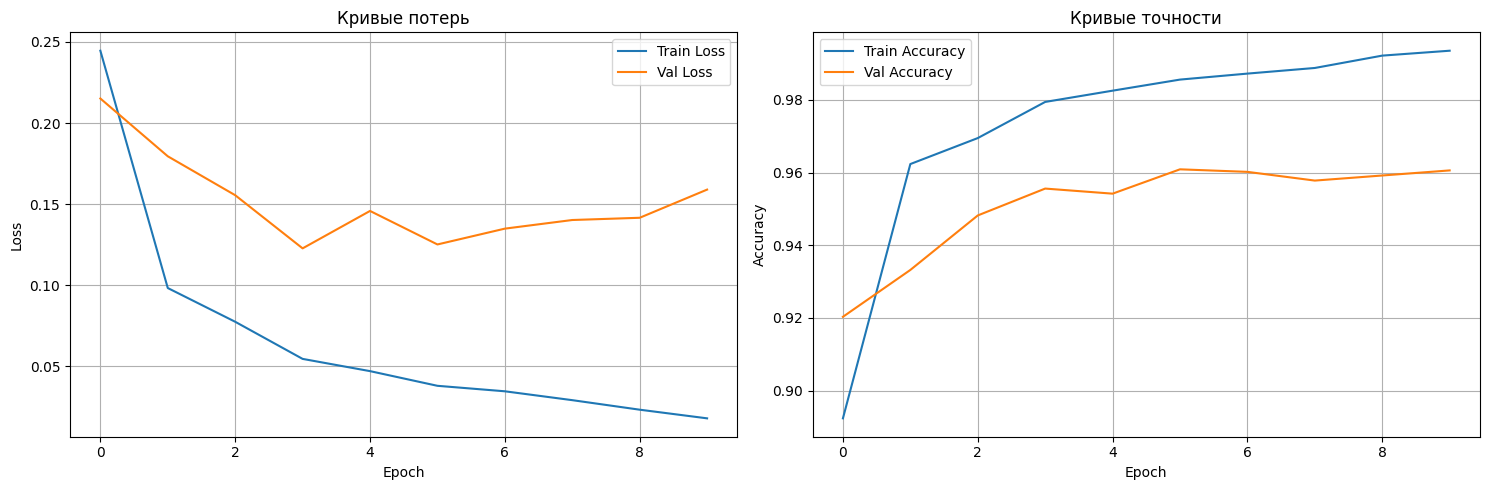


Оценка на тестовом наборе:


Validation: 100%|██████████| 40/40 [00:28<00:00,  1.41it/s]


Тестовая точность: 0.8826
Тестовые потери: 0.4757

Classification Report:
              precision    recall  f1-score   support

        REAL       0.93      0.83      0.88      2500
        FAKE       0.85      0.94      0.89      2500

    accuracy                           0.88      5000
   macro avg       0.89      0.88      0.88      5000
weighted avg       0.89      0.88      0.88      5000



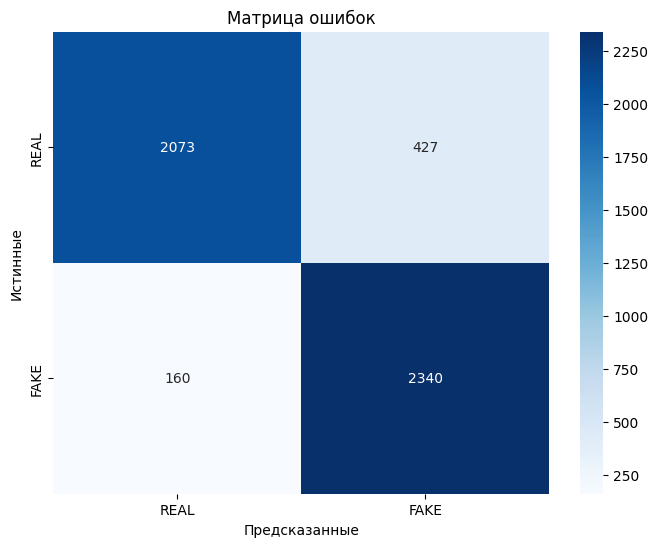

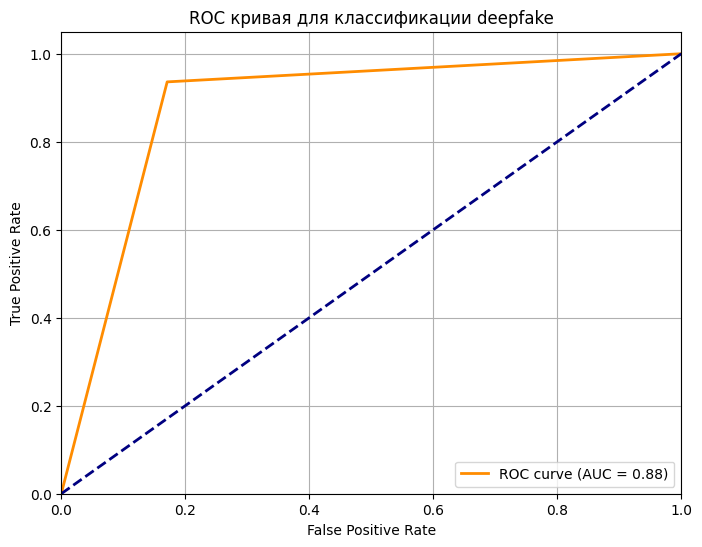

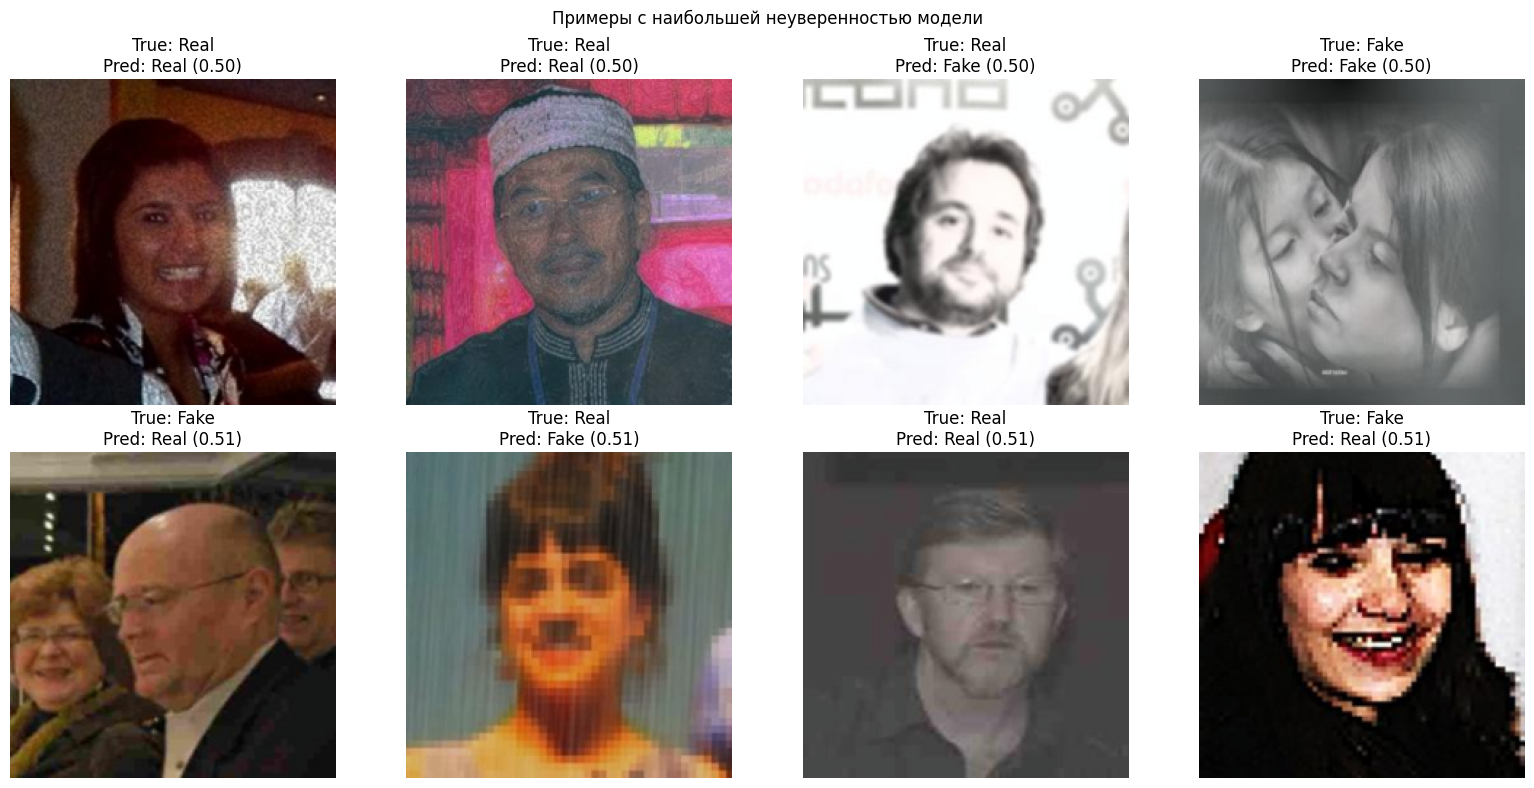


Работа завершена.


In [5]:
# main.py
import os
import json
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Импорты из наших модулей
from config import CONFIG, DEVICE, BATCH_SIZE, LEARNING_RATE, NUM_EPOCHS, WEIGHT_DECAY
from data_utils import load_data, create_dataloaders
from model import HybridRNNTransformerDeepfake
from train_utils import (
    EarlyStopping, train_epoch, validate_epoch,
    plot_learning_curves, evaluate_model, show_uncertain_examples
)

# Установка seed для воспроизводимости
def set_seed(seed):
    import random
    import numpy as np
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(CONFIG['seed'])

# ---------- 1. Загрузка данных ----------
print("Загрузка датасета...")
train_dataset, val_dataset, test_dataset = load_data()
train_loader, val_loader, test_loader = create_dataloaders(
    train_dataset, val_dataset, test_dataset, BATCH_SIZE
)

# ---------- 2. Создание модели ----------
print("\nСоздание модели...")
model = HybridRNNTransformerDeepfake(
    cnn_feature_dim=CONFIG['cnn_feature_dim'],
    lstm_hidden_dim=CONFIG['lstm_hidden_dim'],
    transformer_dim=CONFIG['transformer_dim'],
    num_heads=CONFIG['num_heads'],
    num_layers=CONFIG['num_layers'],
    dropout=CONFIG['dropout']
).to(DEVICE)

# Вывод архитектуры (опционально)
# from torchinfo import summary
# summary(model, input_size=(BATCH_SIZE, 3, CONFIG['img_size'], CONFIG['img_size']))

# ---------- 3. Настройка обучения ----------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
early_stopping = EarlyStopping(patience=7, min_delta=0.001)

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

# ---------- 4. Цикл обучения ----------
print("\nНачало обучения...")
for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")

    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc, _, _ = validate_epoch(model, val_loader, criterion, DEVICE)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    scheduler.step(val_loss)

    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    if early_stopping(val_loss, model):
        print("Ранняя остановка активирована!")
        break

# ---------- 5. Сохранение модели и конфигурации ----------
os.makedirs("models", exist_ok=True)

# Сохраняем веса модели (лучшие, если использовалась ранняя остановка)
torch.save(model.state_dict(), "models/best_model_weights.pth")
print("\nМодель сохранена в models/best_model_weights.pth")

# Сохраняем конфигурацию в JSON
with open("models/config.json", "w") as f:
    json.dump(CONFIG, f, indent=4)
print("Конфигурация сохранена в models/config.json")

# Сохраняем историю обучения (для дальнейшего анализа)
with open("models/history.json", "w") as f:
    json.dump(history, f, indent=4)

# ---------- 6. Визуализация кривых обучения ----------
plot_learning_curves(history)

# ---------- 7. Оценка на тесте ----------
print("\nОценка на тестовом наборе:")
test_acc, test_preds, test_labels = evaluate_model(model, test_loader, criterion, DEVICE)

# ---------- 8. Анализ неуверенных примеров ----------
show_uncertain_examples(model, test_loader, DEVICE, num_examples=8)
